# S06 · Стоимость поездки: модель и прогноз

9 октября 2026. Прогноз оплаченной цены поездки: 64 синтетические поездки, 48 train и 16 test. Сравниваем признаки, проверяем качество и прогнозируем цену новой поездки.

Начните с **Restart Kernel** и выполняйте ячейки сверху вниз. C01, C02 и далее обозначают ячейки. Полная версия с готовыми решениями.

[Описание таблиц и условий](../../data/TAXI-README.md).

## C01 · Подготовка

Импорты и путь к локальным CSV-файлам.

In [1]:
# S06-C01
import csv
from math import sqrt
from pathlib import Path

import matplotlib.pyplot as plt

data_dir = Path("../data")
if not data_dir.exists():
    data_dir = Path("../../data")
if not data_dir.exists():
    data_dir = Path("data")
if not data_dir.exists():
    data_dir = Path("starter/data")
print("Данные:", data_dir)


Данные: ../../data


## C02 · Таблица поездок

64 синтетические поездки: 48 train и 16 test. Признаки при заказе: плановое расстояние в километрах и час пик, 0 или 1. Цель: оплаченная цена в рублях.

In [2]:
# S06-C02
with (data_dir / "taxi-trips-synthetic.csv").open() as file:
    rows = list(csv.DictReader(file))
train_rows = []
test_rows = []
for row in rows:
    if row["split"] == "train":
        train_rows.append(row)
    else:
        test_rows.append(row)
train_x = []
train_peak = []
train_y = []
for row in train_rows:
    train_x.append(float(row["distance_km"]))
    train_peak.append(int(row["peak"]))
    train_y.append(float(row["cost_rub"]))
print("Поездки train и test:", len(train_rows), len(test_rows))


Поездки train и test: 48 16


## C03 · Цены при разных условиях

Цена по расстоянию на 48 обучающих поездках. Цвет обозначает час пик.

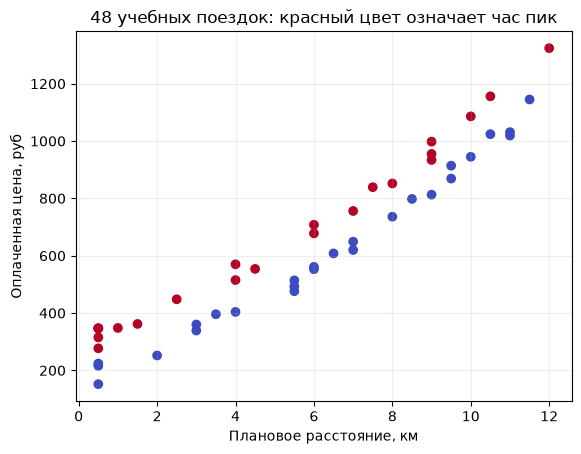

In [3]:
# S06-C03
plt.scatter(train_x, train_y, c=train_peak, cmap="coolwarm")
plt.xlabel("Плановое расстояние, км")
plt.ylabel("Оплаченная цена, руб")
plt.title("48 учебных поездок: красный цвет означает час пик")
plt.grid(alpha=0.2)
plt.show()


## C04 · Среднее и линия по расстоянию

Постоянный прогноз: средняя train-цена. Линия по расстоянию: $\hat y=wx+b$. `fit` находит параметры по train; `predict` вычисляет прогнозы.

In [4]:
# S06-C04
from sklearn.linear_model import LinearRegression

distance_features = []
for distance in train_x:
    distance_features.append([distance])
line_model = LinearRegression()
line_model.fit(distance_features, train_y)
mean_train_cost = sum(train_y) / len(train_y)
print("Линия: w и b:", line_model.coef_[0], line_model.intercept_)
print("Среднее train, руб:", mean_train_cost)


Линия: w и b: 78.49067412624896 186.79890116332638
Среднее train, руб: 642.2083333333334


## C05 · Ошибки простой линии

Ошибка цены $e=\hat y-y$ в рублях. Отрицательная ошибка означает недооценку цены. $\mathrm{MAE}=\frac1n\sum_i|e_i|$, $\mathrm{RMSE}=\sqrt{\frac1n\sum_i e_i^2}$.

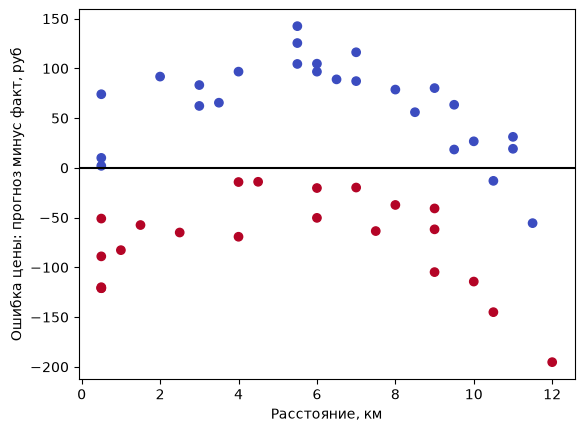

In [5]:
# S06-C05
def error_metrics(actual, predictions):
    absolute_sum = 0.0
    squared_sum = 0.0
    for i in range(len(actual)):
        error = predictions[i] - actual[i]
        absolute_sum = absolute_sum + abs(error)
        squared_sum = squared_sum + error ** 2
    mae = absolute_sum / len(actual)
    mse = squared_sum / len(actual)
    rmse = sqrt(mse)
    return float(mae), rmse

line_train_predictions = line_model.predict(distance_features)
line_errors = []
for i in range(len(train_y)):
    line_errors.append(line_train_predictions[i] - train_y[i])
plt.scatter(train_x, line_errors, c=train_peak, cmap="coolwarm")
plt.axhline(0, color="black")
plt.xlabel("Расстояние, км")
plt.ylabel("Ошибка цены: прогноз минус факт, руб")
plt.show()


## C06 · Задание 1: час пик

Задание 1. Добавьте флаг часа пик во второй столбец признаков. Модель: $\hat y=w_1x+w_2p+b$. Для 5 км в час пик строка равна `[5, 1]`.

In [6]:
# S06-C06
peak_features = []
for i in range(len(train_x)):
    peak_features.append([train_x[i], train_peak[i]])
peak_model = LinearRegression()
peak_model.fit(peak_features, train_y)
print("Коэффициенты и b:", peak_model.coef_, peak_model.intercept_)


Коэффициенты и b: [ 81.62142218 142.67488029] 103.24138661914265


## C07 · Изгиб после учёта часа пик

Ошибки модели с расстоянием и часом пик на обучающих поездках.

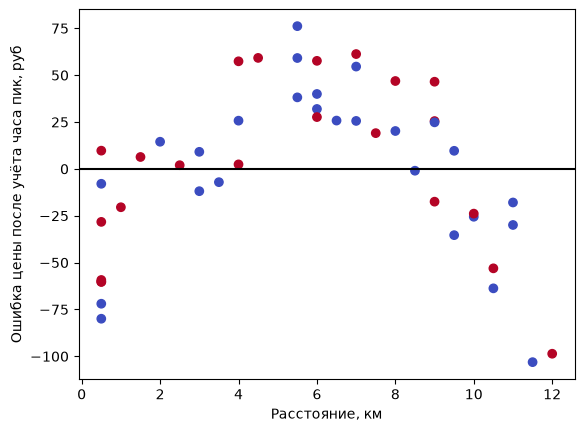

In [7]:
# S06-C07
peak_train_predictions = peak_model.predict(peak_features)
peak_errors = []
for i in range(len(train_y)):
    peak_errors.append(peak_train_predictions[i] - train_y[i])
plt.scatter(train_x, peak_errors, c=train_peak, cmap="coolwarm")
plt.axhline(0, color="black")
plt.xlabel("Расстояние, км")
plt.ylabel("Ошибка цены после учёта часа пик, руб")
plt.show()


## C08 · Задание 2: квадрат расстояния

Задание 2. Добавьте квадрат расстояния. Модель: $\hat y=w_1x+w_2x^2+w_3p+b$. Для 5 км в час пик строка равна `[5, 25, 1]`. Модель линейна по обучаемым коэффициентам.

In [8]:
# S06-C08
shape_features = []
for i in range(len(train_x)):
    distance = train_x[i]
    shape_features.append([distance, distance ** 2, train_peak[i]])
shape_model = LinearRegression()
shape_model.fit(shape_features, train_y)
print("Коэффициенты и b:", shape_model.coef_, shape_model.intercept_)


Коэффициенты и b: [ 42.58004896   3.44678304 133.87340699] 173.10838893534225


## C09 · Проверка на 16 новых поездках

Четыре заранее заданных варианта проверяются на одних 16 test-поездках. Их фактические цены не участвуют в обучении.

In [9]:
# S06-C09
test_y = []
test_distance = []
test_peak = []
test_shape = []
constant_predictions = []
for row in test_rows:
    distance = float(row["distance_km"])
    peak = int(row["peak"])
    test_y.append(float(row["cost_rub"]))
    test_distance.append([distance])
    test_peak.append([distance, peak])
    test_shape.append([distance, distance ** 2, peak])
    constant_predictions.append(mean_train_cost)
line_test_predictions = line_model.predict(test_distance)
peak_test_predictions = peak_model.predict(test_peak)
shape_test_predictions = shape_model.predict(test_shape)
print("Среднее, MAE и RMSE:", error_metrics(test_y, constant_predictions))
print("Расстояние, MAE и RMSE:", error_metrics(test_y, line_test_predictions))
print("Расстояние и пик:", error_metrics(test_y, peak_test_predictions))
print("Расстояние, квадрат и пик:", error_metrics(test_y, shape_test_predictions))


Среднее, MAE и RMSE: (243.4375, 265.370999472646)
Расстояние, MAE и RMSE: (69.37849720265666, 75.45201920910787)
Расстояние и пик: (27.816148791423203, 33.30501579944399)
Расстояние, квадрат и пик: (19.358458079602187, 22.927671761863046)


## C10 · Задание 3: цена новой поездки

Задание 3. Вычислите прогноз цены: расстояние 5 км, час пик, бюджет 700 рублей. `new_trip` содержит одну строку признаков; нужен первый результат `predict`.

In [10]:
# S06-C10
new_trip = [[5.0, 25.0, 1]]
new_prediction = shape_model.predict(new_trip)[0]
print("Прогноз, руб:", round(new_prediction))
print("Запас до 700 рублей:", 700 - new_prediction)


Прогноз, руб: 606
Запас до 700 рублей: 93.948383347966


## C11 · Отдельный чек 1800 рублей

Дополнительная синтетическая поездка: 3 км вне часа пик, оплачено 1800 рублей. Она добавляется к копии train. Исходные данные и 16 test-поездок сохраняются.

In [11]:
# S06-C11
with (data_dir / "taxi-extra-trip.csv").open() as file:
    extra_rows = list(csv.DictReader(file))
extra_distance = float(extra_rows[0]["distance_km"])
extra_peak = int(extra_rows[0]["peak"])
extra_cost = float(extra_rows[0]["cost_rub"])
changed_features = shape_features + [[extra_distance, extra_distance ** 2, extra_peak]]
changed_y = train_y + [extra_cost]
changed_model = LinearRegression()
changed_model.fit(changed_features, changed_y)
print("Цена поездки 5 км до и после:", new_prediction, changed_model.predict(new_trip)[0])


Цена поездки 5 км до и после: 606.051616652034 622.5593500412642


## C12 · Сравнение на одинаковых поездках

Исходная и пересчитанная модели оцениваются на одних 49 train-поездках и на одних 16 test-поездках.

In [12]:
# S06-C12
old_changed_predictions = shape_model.predict(changed_features)
new_changed_predictions = changed_model.predict(changed_features)
print("49 train, до:", error_metrics(changed_y, old_changed_predictions))
print("49 train, после:", error_metrics(changed_y, new_changed_predictions))
changed_test_predictions = changed_model.predict(test_shape)
print("16 test, до:", error_metrics(test_y, shape_test_predictions))
print("16 test, после:", error_metrics(test_y, changed_test_predictions))


49 train, до: (48.69720221944947, 210.88160927162758)
49 train, после: (72.06075391042245, 204.8532788973993)
16 test, до: (19.358458079602187, 22.927671761863046)
16 test, после: (38.20805468312639, 52.848212404706516)


## C13 · Как чек изменил правило цены

Две кривые прогноза цены вне часа пик: до и после добавления дорогой поездки. Точки соответствуют обучающим поездкам.

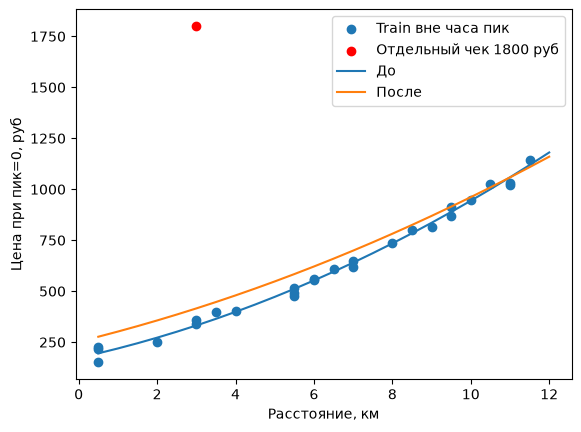

In [13]:
# S06-C13
quiet_x = []
quiet_y = []
for i in range(len(train_x)):
    if train_peak[i] == 0:
        quiet_x.append(train_x[i])
        quiet_y.append(train_y[i])
line_x = []
line_features = []
for i in range(1, 25):
    distance = i / 2
    line_x.append(distance)
    line_features.append([distance, distance ** 2, 0])
plt.scatter(quiet_x, quiet_y, label="Train вне часа пик")
plt.scatter([extra_distance], [extra_cost], color="red", label="Отдельный чек 1800 руб")
plt.plot(line_x, shape_model.predict(line_features), label="До")
plt.plot(line_x, changed_model.predict(line_features), label="После")
plt.xlabel("Расстояние, км")
plt.ylabel("Цена при пик=0, руб")
plt.legend()
plt.show()


## C14 · Вывод по задаче

Три случая: перевод копеек в рубли, подтверждённый дорогой чек и прогноз новой поездки. Итог: модель, MAE/RMSE на test, прогноз и условия применения.

In [14]:
# S06-C14
print("A: в чеке 180000 копеек, в таблице единица рубли")
print("B: чек подтверждает 1800 рублей за одну поездку")
print("C: модель даёт цену поездки 5 км в час пик")


A: в чеке 180000 копеек, в таблице единица рубли
B: чек подтверждает 1800 рублей за одну поездку
C: модель даёт цену поездки 5 км в час пик


## Результат

Модель, ошибка на проверочных данных и прогноз для нового заказа или поездки. Все наблюдения синтетические.